# SLAM Navigation Hackathon

**Participant:** `teilnehmer9-alexz`  
**Topic:** SLAM debugging and navigation  

Design your own abstractions for mapping, path submission, and obstacle-aware navigation.

Hackathon target: produce the most impressive navigation demo with obstacle avoidance, while keeping the code readable and modular.

## Required context

The Livox-related visualization material for this lab is in:

- `/home/ag/ef_ws/g1/docs`
- `/home/ag/ef_ws/g1/modules/scripts/slam_points_viewer.py`
- `/home/ag/ef_ws/g1/dev/old_scripts/navigation/slam`

Read those resources before blaming your code. In this workspace, the path mentioned in the brief as `../ef_ws/g1/navigation/slam` is not present; the closest matching material is under the paths above.

In [2]:
from sdk_client import Robot
import time
import math
import pandas as pd

iface = 'enp1s0'
robot = Robot(iface)


## Session bootstrap

Start by checking whether odom and SLAM pose are both available. A navigation abstraction is only useful if it can explain when pose data is not ready.

In [3]:
status = robot.get_slam_pose_status()
{
    'odom_pose': robot.get_odom_pose(),
    'slam_status': status,
    'slam_info': robot.get_slam_info(),
}

{'odom_pose': None,
 'slam_status': {'pose': (0.0, 0.0, 0.0),
  'sport_pose': (-0.11167222261428833,
   -0.052224837243556976,
   0.7086849212646484),
  'slam_running': False,
  'usable': True,
  'reason': 'ok',
  'sport_vs_slam_xy_gap_m': 0.12328065107197961},
 'slam_info': '{\n    "data": {\n        "currentPose": {\n            "pitch": 0.0,\n            "roll": 0.0,\n            "x": 0.0,\n            "y": 0.0,\n            "yaw": 0.0,\n            "z": 0.0\n        },\n        "is_arrived": false,\n        "obsInfo": {\n            "state": false,\n            "time": 0.0\n        },\n        "progress": {\n            "completion_percentage": 0.0,\n            "last_time": 0.0,\n            "used_time": 0.0\n        },\n        "startPose": {\n            "pitch": 0.0,\n            "roll": 0.0,\n            "x": 0.0,\n            "y": 0.0,\n            "yaw": 0.0,\n            "z": 0.0\n        },\n        "stateMachine": {\n            "ctrName": "not init",\n            "isBack

In [4]:
def wait_for_usable_pose(robot, timeout_s=8.0, poll_s=0.25):
    deadline = time.time() + float(timeout_s)
    history = []
    while time.time() < deadline:
        status = robot.get_slam_pose_status()
        history.append(status)
        if status.get('usable'):
            return status, history
        time.sleep(poll_s)
    return None, history


## Mapping helpers

These are thin wrappers on purpose. Replace them with your own abstractions once you understand the workflow.

In [5]:
def start_mapping_session(robot, slam_type='indoor'):
    rc = robot.start_slam(slam_type=slam_type)
    print('start_slam rc =', rc)
    return rc


def stop_mapping_session(robot, save_path=None):
    rc = robot.stop_slam(save_path=save_path)
    print('stop_slam rc =', rc)
    return rc


In [6]:
def queue_demo_route(robot):
    """Queue a tiny demo route. Replace it with your own route abstraction."""
    robot.clear_path_points()
    robot.set_path_point(0.8, 0.0, 0.0)
    robot.set_path_point(0.8, 0.5, math.radians(45))
    robot.set_path_point(0.2, 0.5, math.radians(90))
    return robot.get_path_points()

queue_demo_route(robot)

[(0.8, 0.0, 0.0),
 (0.8, 0.5, 0.7853981633974483),
 (0.2, 0.5, 1.5707963267948966)]

In [7]:
def avoid_obstacle_stub(robot, near_distance_m=0.7, max_points=3000):
    """Example obstacle check using lidar point samples. Extend this."""
    points = robot.get_lidar_points(max_points=max_points)
    near = []
    for p in points:
        x = float(p['x'])
        y = float(p['y'])
        dist = math.hypot(x, y)
        if 0.05 < dist < float(near_distance_m):
            near.append((x, y, dist))
    return {
        'point_count': len(points),
        'near_count': len(near),
        'nearest': None if not near else min(near, key=lambda item: item[2]),
        'should_stop': len(near) > 0,
    }

avoid_obstacle_stub(robot)

{'point_count': 0, 'near_count': 0, 'nearest': None, 'should_stop': False}

In [8]:
def run_navigation_mission(robot):
    status, history = wait_for_usable_pose(robot)
    if status is None:
        raise RuntimeError('SLAM pose never became usable. Inspect history before retrying.')
    obstacle = avoid_obstacle_stub(robot)
    if obstacle['should_stop']:
        print('Obstacle warning:', obstacle)
        return False
    queue_demo_route(robot)
    return robot.navigate_path()


## Suggested workflow

1. Start a mapping session.
2. Move the robot and verify the pose becomes usable.
3. Visualize the point cloud with the Livox-related tooling from the docs/workspace paths above.
4. Improve the obstacle check so it does more than a binary stop/no-stop decision.
5. Run a navigation showcase route.

In [9]:
# start_mapping_session(robot)
# mission_ok = run_navigation_mission(robot)
# stop_mapping_session(robot)

In [10]:
def setup_mapping(robot, slam_type='indoor', timeout_s=8.0):
    """Start SLAM and wait for a usable pose. Returns a status dict."""
    rc = robot.start_slam(slam_type=slam_type)
    print(f'start_slam rc={rc}')
    status, history = wait_for_usable_pose(robot, timeout_s=timeout_s)
    return {
        'rc': rc,
        'usable': status is not None,
        'final_status': status if status else (history[-1] if history else None),
        'attempts': len(history),
    }

## Your TODOs

- Package map setup, relocalization checks, and route execution into your own named abstractions.
- Explain at least one failure mode using the data from `get_slam_pose_status()`.
- Extend obstacle handling beyond a simple stop: reroute, wait, or shrink the goal.
- Keep notes on what the viewer shows versus what `get_lidar_points()` reports.

In [11]:
def diagnose_lidar(robot):
    print('Sensor staleness (max_age=2s):')
    for name, stale in robot.sensors_stale(max_age=2.0).items():
        if 'lidar' in name:
            print(f'  {name}: {"STALE" if stale else "OK"}')

    print('\nLatest lidar cloud info:')
    cloud = robot.get_lidar_cloud()
    if cloud is None:
        print('  None')
        return
    print(f"  topic       = {cloud['topic']}")
    print(f"  frame_id    = {cloud['frame_id']}")
    print(f"  width       = {cloud['width']}")
    print(f"  height      = {cloud['height']}")
    print(f"  point_step  = {cloud['point_step']}")
    print(f"  point_count = {cloud['point_count']} (after parsing)")
    if cloud['points']:
        p = cloud['points'][0]
        print(f"  first point = x={p['x']:.3f} y={p['y']:.3f} z={p['z']:.3f}")

diagnose_lidar(robot)

Sensor staleness (max_age=2s):
  lidar_map: STALE
  lidar_cloud: STALE
  lidar_cloud[rt/unitree/slam_mapping/points]: STALE
  lidar_cloud[rt/unitree/slam_relocation/points]: STALE
  lidar_cloud[rt/utlidar/cloud_deskewed]: STALE
  lidar_cloud[rt/utlidar/cloud_livox_mid360]: STALE

Latest lidar cloud info:
  None


In [12]:
import plotly.graph_objects as go
from IPython.display import display, clear_output
import time

def lidar_3d_view(robot, max_points=15000, color_by='z'):
    """Static 3D scatter of the latest lidar frame, colored as a heatmap.
    color_by: 'z' (height), 'distance', or 'intensity_proxy'
    """
    points = robot.get_lidar_points(max_points=max_points)
    if not points:
        print('No lidar points received.')
        return
    xs = [p['x'] for p in points]
    ys = [p['y'] for p in points]
    zs = [p['z'] for p in points]

    if color_by == 'z':
        cvals, label, scale = zs, 'height z (m)', 'Viridis'
    elif color_by == 'distance':
        cvals = [(x*x + y*y + z*z) ** 0.5 for x, y, z in zip(xs, ys, zs)]
        label, scale = 'distance (m)', 'Turbo'
    else:
        cvals = [(x*x + y*y) ** 0.5 for x, y, z in zip(xs, ys, zs)]
        label, scale = 'horizontal range (m)', 'Plasma'

    fig = go.Figure(data=[
        go.Scatter3d(
            x=xs, y=ys, z=zs, mode='markers',
            marker=dict(size=1.8, color=cvals, colorscale=scale,
                        colorbar=dict(title=label), opacity=0.85),
            hovertemplate='x=%{x:.2f}<br>y=%{y:.2f}<br>z=%{z:.2f}<extra></extra>',
        ),
        go.Scatter3d(
            x=[0], y=[0], z=[0], mode='markers',
            marker=dict(size=8, color='red', symbol='diamond'),
            name='robot',
        ),
    ])
    fig.update_layout(
        title=f'Lidar cloud — {len(points)} pts — colored by {label}',
        scene=dict(
            xaxis_title='x forward (m)',
            yaxis_title='y left (m)',
            zaxis_title='z up (m)',
            aspectmode='data',
        ),
        width=900, height=750, margin=dict(l=0, r=0, t=40, b=0),
    )
    fig.show()

lidar_3d_view(robot, color_by='z')

No lidar points received.


In [17]:
def live_lidar_3d(robot, duration_s=30, refresh_s=1.5, max_points=12000):
    import plotly.graph_objects as go
    from IPython.display import display, clear_output
    
    t0 = time.time()
    while time.time() - t0 < duration_s:
        points = robot.get_lidar_points(max_points=max_points)
        if not points:
            print('No points. Skipping frame.')
            time.sleep(refresh_s)
            continue
        xs = [p['x'] for p in points]
        ys = [p['y'] for p in points]
        zs = [p['z'] for p in points]

        fig = go.Figure(data=[
            go.Scatter3d(x=xs, y=ys, z=zs, mode='markers',
                marker=dict(size=1.8, color=zs, colorscale='Viridis',
                            colorbar=dict(title='z (m)'), opacity=0.85)),
            go.Scatter3d(x=[0], y=[0], z=[0], mode='markers',
                marker=dict(size=8, color='red'), name='robot'),
        ])
        fig.update_layout(
            title=f't={time.time()-t0:.1f}s  pts={len(points)}',
            scene=dict(aspectmode='data',
                       xaxis_title='x', yaxis_title='y', zaxis_title='z'),
            width=850, height=700, margin=dict(l=0, r=0, t=40, b=0),
        )
        clear_output(wait=True)
        display(fig)
        time.sleep(refresh_s)

live_lidar_3d(robot, duration_s=30, refresh_s=1.5)

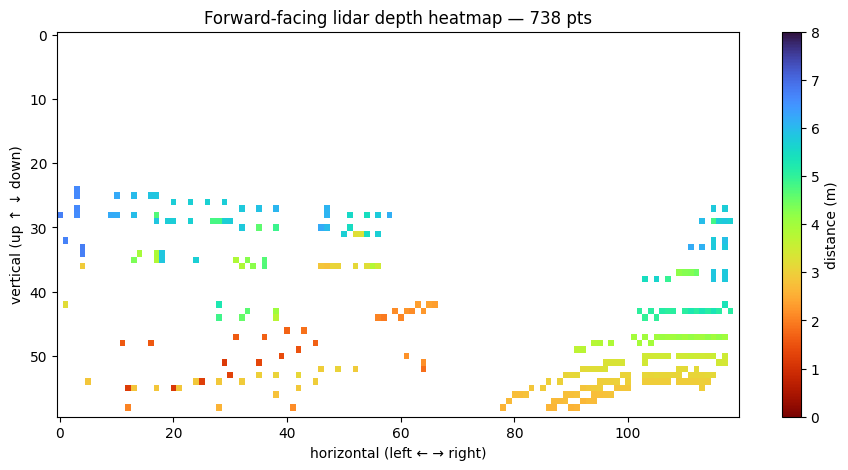

In [19]:
def lidar_depth_heatmap(robot, h=60, w=120, max_points=20000,
                        h_fov_deg=180, v_fov_deg=60, max_range=8.0):
    """Project lidar into a forward-facing depth heatmap (looks like a depth camera)."""
    import numpy as np
    import matplotlib.pyplot as plt

    points = robot.get_lidar_points(max_points=max_points)
    if not points:
        print('No points.')
        return

    img = np.full((h, w), np.nan)
    h_fov = math.radians(h_fov_deg)
    v_fov = math.radians(v_fov_deg)

    for p in points:
        x, y, z = p['x'], p['y'], p['z']
        if x <= 0.05:
            continue
        r = math.sqrt(x*x + y*y + z*z)
        if r > max_range:
            continue
        yaw   = math.atan2(y, x)
        pitch = math.atan2(z, math.sqrt(x*x + y*y))
        if abs(yaw) > h_fov / 2 or abs(pitch) > v_fov / 2:
            continue
        u = int((1 - (yaw + h_fov/2) / h_fov) * (w - 1))
        v = int((1 - (pitch + v_fov/2) / v_fov) * (h - 1))
        if 0 <= u < w and 0 <= v < h:
            if math.isnan(img[v, u]) or r < img[v, u]:
                img[v, u] = r

    fig, ax = plt.subplots(figsize=(11, 5))
    im = ax.imshow(img, cmap='turbo_r', vmin=0, vmax=max_range, aspect='auto')
    fig.colorbar(im, ax=ax, label='distance (m)')
    ax.set_title(f'Forward-facing lidar depth heatmap — {len(points)} pts')
    ax.set_xlabel('horizontal (left ← → right)')
    ax.set_ylabel('vertical (up ↑ ↓ down)')
    plt.show()

lidar_depth_heatmap(robot)

In [15]:
def diagnose_lidar(robot):
    print('── Lidar staleness ──')
    for name, stale in robot.sensors_stale(max_age=2.0).items():
        if 'lidar' in name:
            print(f'  {name}: {"STALE ❌" if stale else "OK ✓"}')

    print('\n── Latest cloud message ──')
    cloud = robot.get_lidar_cloud()
    if cloud is None:
        print('  None — keine Nachricht empfangen')
        return
    print(f"  topic       = {cloud['topic']}")
    print(f"  width × height = {cloud['width']} × {cloud['height']}")
    print(f"  point_step  = {cloud['point_step']} bytes")
    print(f"  parsed pts  = {cloud['point_count']}")
    print(f"  frame_id    = {cloud['frame_id']}")

diagnose_lidar(robot)

── Lidar staleness ──
  lidar_map: STALE ❌
  lidar_cloud: OK ✓
  lidar_cloud[rt/unitree/slam_mapping/points]: OK ✓
  lidar_cloud[rt/unitree/slam_relocation/points]: STALE ❌
  lidar_cloud[rt/utlidar/cloud_deskewed]: STALE ❌
  lidar_cloud[rt/utlidar/cloud_livox_mid360]: STALE ❌

── Latest cloud message ──
  topic       = rt/unitree/slam_mapping/points
  width × height = 1415 × 1
  point_step  = 48 bytes
  parsed pts  = 1415
  frame_id    = map


In [ ]:
import plotly.graph_objects as go
from IPython.display import display
import time, math, threading

def live_lidar_3d_efficient(robot, duration_s=60, refresh_s=0.5, max_points=10000):
    """Live 3D lidar using FigureWidget — only data updates, no redraw."""
    
    # initial frame
    points = robot.get_lidar_points(max_points=max_points)
    xs = [p['x'] for p in points] or [0]
    ys = [p['y'] for p in points] or [0]
    zs = [p['z'] for p in points] or [0]

    fig = go.FigureWidget(data=[
        go.Scatter3d(x=xs, y=ys, z=zs, mode='markers',
            marker=dict(size=1.8, color=zs, colorscale='Viridis',
                        colorbar=dict(title='z (m)'), opacity=0.85)),
        go.Scatter3d(x=[0], y=[0], z=[0], mode='markers',
            marker=dict(size=8, color='red', symbol='diamond'), name='robot'),
    ])
    fig.update_layout(
        scene=dict(aspectmode='data',
                   xaxis_title='x forward (m)',
                   yaxis_title='y left (m)',
                   zaxis_title='z up (m)'),
        width=850, height=700, margin=dict(l=0, r=0, t=30, b=0),
        title=f'Live lidar — {len(points)} pts',
    )
    display(fig)

    # update loop — only mutates trace data
    t0 = time.time()
    try:
        while time.time() - t0 < duration_s:
            points = robot.get_lidar_points(max_points=max_points)
            if points:
                xs = [p['x'] for p in points]
                ys = [p['y'] for p in points]
                zs = [p['z'] for p in points]
                with fig.batch_update():
                    fig.data[0].x = xs
                    fig.data[0].y = ys
                    fig.data[0].z = zs
                    fig.data[0].marker.color = zs
                    fig.layout.title.text = f't={time.time()-t0:.1f}s  pts={len(points)}'
            time.sleep(refresh_s)
    except KeyboardInterrupt:
        print('Stopped.')

live_lidar_3d_efficient(robot, duration_s=60, refresh_s=0.5)

FigureWidget({
    'data': [{'marker': {'color': [0.9409999847412109, 1.0, 0.9470000267028809,
                                   ..., 0.9520000219345093, 0.9279999732971191,
                                   0.9150000214576721],
                         'colorbar': {'title': {'text': 'z (m)'}},
                         'colorscale': [[0.0, '#440154'], [0.1111111111111111,
                                        '#482878'], [0.2222222222222222,
                                        '#3e4989'], [0.3333333333333333,
                                        '#31688e'], [0.4444444444444444,
                                        '#26828e'], [0.5555555555555556,
                                        '#1f9e89'], [0.6666666666666666,
                                        '#35b779'], [0.7777777777777778,
                                        '#6ece58'], [0.8888888888888888,
                                        '#b5de2b'], [1.0, '#fde725']],
                         'opacity': 0.85,